# Deep Operator Network (DeepONets) in Neuromancer: Learning nonlinear operators

This tutorial demonstrates the use of Deep Operator Network (DeepONets) for solving partial differential equations (PDEs) in the Neuromancer library.

<img src="https://media.springernature.com/lw685/springer-static/image/art%3A10.1038%2Fs42256-021-00302-5/MediaObjects/42256_2021_302_Fig1_HTML.png" width="700">  

## Deep Operator Networks (DeepONets)

DeepONets are neural networks designed to learn **operators**, i.e. mappings between functions,
$$
\mathcal{G} : v(\cdot) \;\mapsto\; u(\cdot),
$$
where $ v $ is an input function (e.g. a source term or coefficient field) and $ u $ is the corresponding output function (e.g. the PDE solution).

A DeepONet represents the operator evaluation at a point $ x $ as
$$
u(x) \approx \sum_{k=1}^{p} b_k(v)\, t_k(x),
$$
where:
- $ b_k(v) $ are outputs of the **branch network**, which encodes the input function $ v $ sampled at fixed sensor locations,
- $ t_k(x) $ are outputs of the **trunk network**, which encodes the spatial coordinate $ x $,
- $ p $ is the latent dimension.

Equivalently, this can be written as an inner product:
$$
u(x) \approx \mathbf{b}(v)^\top \mathbf{t}(x).
$$

In the **Cartesian-product formulation**, the same branch encoding $ \mathbf{b}(v) $ is paired with many spatial locations $ x $, allowing efficient evaluation of the output function on structured grids.

DeepONets provide a principled framework for learning solution operators of partial differential equations and have universal approximation properties for nonlinear operators.

### References

[1] [Lu, L., Jin, P., Pang, G. et al. Learning nonlinear operators via DeepONet based on the universal approximation theorem of operators. Nat Mach Intell 3, 218–229 (2021).](https://www.nature.com/articles/s42256-021-00302-5)

[2] https://github.com/jdtoscano94/Learning-Python-Physics-Informed-Machine-Learning-PINNs-DeepONets/tree/main

[3] [Lu, L., Meng, X., Cai, S., Mao, Z., Goswami, S., Zhang, Z., & Karniadakis, G. E. (2022). A comprehensive and fair comparison of two neural operators (with practical extensions) based on fair data. Computer Methods in Applied Mechanics and Engineering, 393, 114778.](https://www.sciencedirect.com/science/article/pii/S0045782522001207?via%3Dihub)

# Antiderivative Operator - Aligned Dataset

This tutorial demonstrates the use of learning DeepONets for a data driven use case (non-physics informed). This tutorial demonstrates usage of a Cartesian-product DeepONet implemented in Neuromancer, which is compatible with `neuromancer.modules.blocks` (or any `nn.Module`). The capability to use DeepONets from DeepXDE library within Neuromancer is also demonstrated. Here, we use `dde.nn.DeepONetCartesianProd` with the PyTorch backend `os.environ["DDE_BACKEND"] = "pytorch"`


### References
[1] [Antiderivative operator from an aligned dataset - DeepXDE](https://deepxde.readthedocs.io/en/latest/demos/operator/antiderivative_aligned.html)

[2] [DeepONet Tutorial in JAX](https://github.com/Ceyron/machine-learning-and-simulation/blob/main/english/neural_operators/simple_deepOnet_in_JAX.ipynb)

[3] [DeepXDE DeepONet PyTorch backend](https://deepxde.readthedocs.io/en/stable/_modules/deepxde/nn/pytorch/deeponet.html#)

[4] https://docs.nvidia.com/physicsnemo/25.08/physicsnemo-sym/user_guide/neural_operators/deeponet.html

### Install (Colab only)

In [10]:
# %pip install "neuromancer[examples] @ git+https://github.com/pnnl/neuromancer.git@master"
# %pip install watermark

### Imports

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

os.environ["DDE_BACKEND"] = "pytorch"
import deepxde as dde


Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [2]:
# PyTorch random seed
torch.manual_seed(1234)

# NumPy random seed
np.random.seed(1234)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Problem Setup

original source: [https://github.com/lululxvi/deepxde/blob/master/examples/operator/poisson_1d_pideeponet.py](https://github.com/lululxvi/deepxde/blob/master/examples/operator/poisson_1d_pideeponet.py)  

We will learn the 1D Poisson operator:

$$G : v \mapsto u$$

Find u on [0,1] such that -u_xx(x) = f(x) with Dirichlet u(0)=u(1)=0. Here f is not fixed; we learn the solution operator that maps any admissible f (from a small function space) to its corresponding u.

## Problem definition

In [4]:
# Poisson equation: -u_xx = f
def equation(x, y, f):
    dy_xx = dde.grad.hessian(y, x)
    return -dy_xx - f

In [ ]:
# Domain is interval [0, 1]
geom = dde.geometry.Interval(0, 1)


# Zero Dirichlet BC
def u_boundary(_):
    return 0


def boundary(_, on_boundary):
    return on_boundary


# Dirichlet u(0)=u(1)=0
bc = dde.icbc.DirichletBC(geom, u_boundary, boundary)

## Dataset Prep

PDE residual points: `num_domain=100` interior samples from geom (`pde.train_x` stores them, plus boundary points)

In [5]:
# Define PDE
pde = dde.data.PDE(geom, equation, bc, num_domain=100, num_boundary=2)

In [22]:
print(pde.test_x.shape)  # (102, 1)
# print(pde.train_x_bc.shape)  # (102, 1)
# print(pde.train_x.shape)  # (102, 1)

(104, 1)


In [25]:
n_bc = sum(pde.num_bcs)
print("train_x", pde.train_x.shape)
print("test_x ", pde.test_x.shape)
print("BC identical? ", np.allclose(pde.test_x[:n_bc], pde.train_x_bc))
print("PDE identical?", np.allclose(pde.test_x[n_bc:], pde.train_x_all))

train_x (104, 1)
test_x  (104, 1)
BC identical?  True
PDE identical? True


In [23]:
print(pde.train_x_all.shape)  # (102, 1)
print(pde.train_x_bc.shape)  # (102, 1)
print(pde.train_x.shape)  # (102, 1)

(102, 1)
(2, 1)
(104, 1)


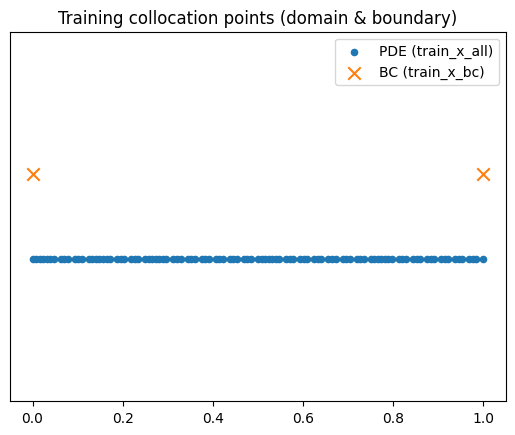

In [20]:
# grab points
X_bc = np.asarray(pde.train_x_bc)[:, 0]  # boundary points
X_pde = np.asarray(pde.train_x_all)[:, 0]  # interior PDE points

plt.figure()
plt.scatter(X_pde, np.zeros_like(X_pde), s=20, label="PDE (train_x_all)")
plt.scatter(X_bc, np.zeros_like(X_bc) + 0.03, s=80, marker="x", label="BC (train_x_bc)")
plt.yticks([])
plt.ylim(-0.05, 0.08)
plt.title("Training collocation points (domain & boundary)")
plt.legend()
plt.show()

## Discretised $f$ for branch net

Here $f$ is not fixed; we learn the solution operator that maps any admissible $f$ (from a small function space) to its corresponding $u$

In [6]:
# Function space for f(x) are polynomials
degree = 3
space = dde.data.PowerSeries(N=degree + 1)

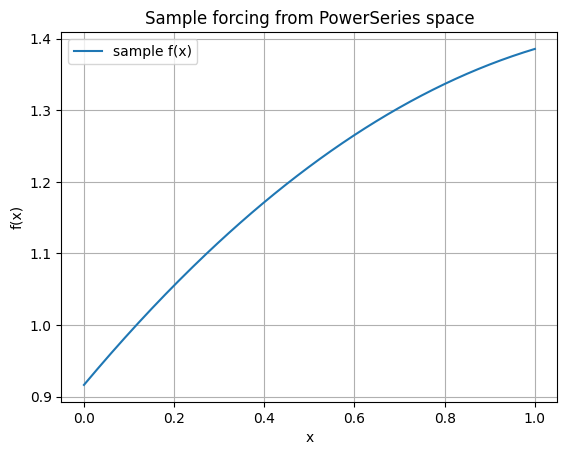

In [10]:
# sample one coefficient vector and build f(x)
coeffs = space.random(11)[0]  # shape (degree+1,)
xs = np.linspace(0, 1, 200)
f_vals = sum(coeffs[k] * xs**k for k in range(len(coeffs)))

plt.figure()
plt.plot(xs, f_vals, label="sample f(x)")
plt.title("Sample forcing from PowerSeries space")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

We chose to evaluate $f$ on `num_eval_points = 10` points. They are uniformly spaced

In [ ]:
# Choose evaluation points, amrk on geom
num_eval_points = 10
evaluation_points = geom.uniform_points(num_eval_points, boundary=True)

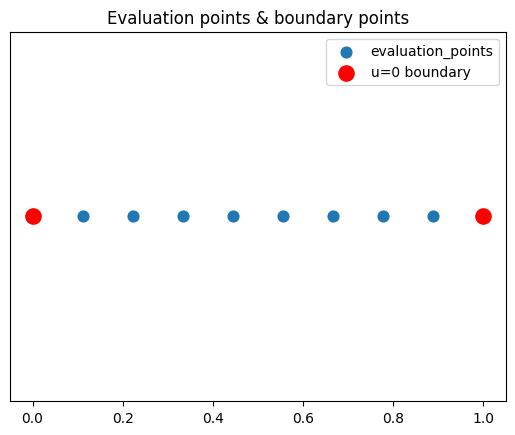

In [32]:
plt.figure()
plt.scatter(
    evaluation_points, np.zeros_like(evaluation_points), s=60, label="evaluation_points"
)
plt.scatter([0, 1], [0, 0], color="red", s=120, label="u=0 boundary")
plt.yticks([])
plt.ylim(-0.1, 0.1)
plt.xlim(-0.05, 1.05)
plt.title("Evaluation points & boundary points")
plt.legend()
plt.show()

In [26]:
# Define PDE operator
pde_op = dde.data.PDEOperatorCartesianProd(
    pde,
    space,
    evaluation_points,
    num_function=100,
)

Function space for $f$: ``PowerSeries(N=degree+1)`` with `degree`=3, so each random $f$ is a polynomial $a_0 + a_1 x + a_2 x^2 + a_3 x^3$; 

`space.random(num_function)` samples the coefficients.


In [27]:
# Plot realisations of f(x)
n = 3
features = space.random(n)
fx = space.eval_batch(features, evaluation_points)

/tmp/ipykernel_1337982/3566315638.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


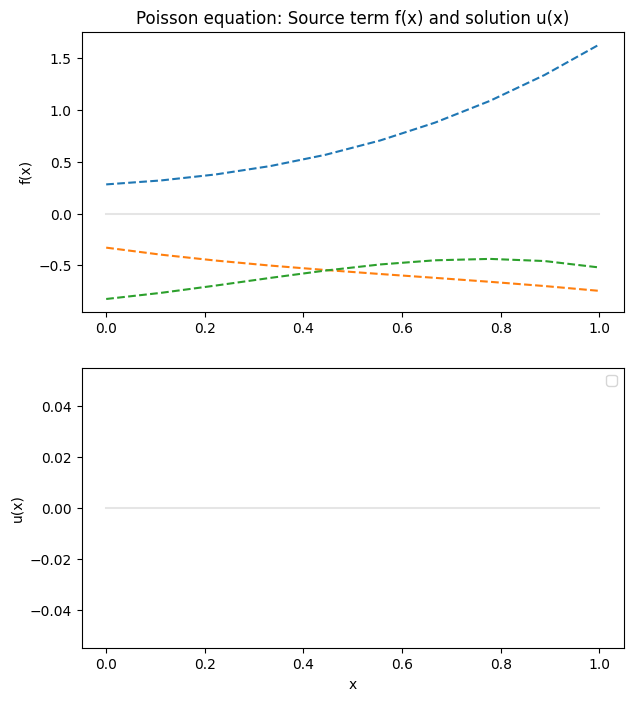

In [29]:
x = geom.uniform_points(100, boundary=True)

# Setup figure
fig = plt.figure(figsize=(7, 8))
plt.subplot(2, 1, 1)
plt.title("Poisson equation: Source term f(x) and solution u(x)")
plt.ylabel("f(x)")
z = np.zeros_like(x)
plt.plot(x, z, "k-", alpha=0.1)

# Plot source term f(x)
for i in range(n):
    plt.plot(evaluation_points, fx[i], "--")

# Plot solution u(x)
plt.subplot(2, 1, 2)
plt.ylabel("u(x)")
plt.plot(x, z, "k-", alpha=0.1)
# for i in range(n):
#     plt.plot(x, y[i], "-")
plt.xlabel("x")
plt.legend()

plt.show()

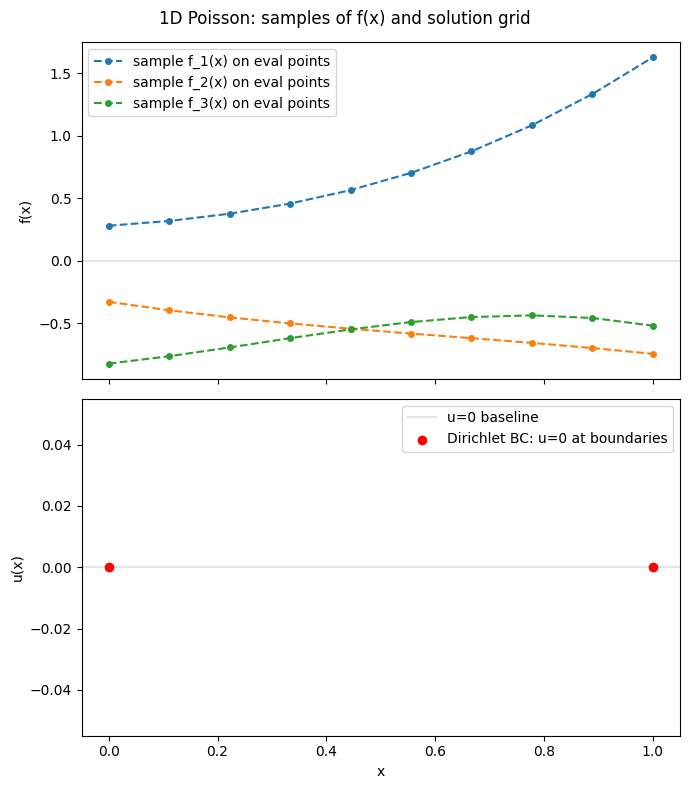

In [30]:
x = geom.uniform_points(100, boundary=True)
z = np.zeros_like(x)

fig, (ax_f, ax_u) = plt.subplots(2, 1, figsize=(7, 8), sharex=True)
fig.suptitle("1D Poisson: samples of f(x) and solution grid")

# Source terms f(x)
ax_f.set_ylabel("f(x)")
ax_f.axhline(0, color="k", alpha=0.1)
for i in range(n):
    ax_f.plot(
        evaluation_points,
        fx[i],
        "--o",
        ms=4,
        label=f"sample f_{i + 1}(x) on eval points",
    )
ax_f.legend()

# Solution u(x) (placeholder)
ax_u.set_ylabel("u(x)")
ax_u.set_xlabel("x")
ax_u.axhline(0, color="k", alpha=0.1, label="u=0 baseline")
ax_u.scatter(
    [0, 1], [0, 0], color="red", zorder=3, label="Dirichlet BC: u=0 at boundaries"
)
# when you have predictions, add them, e.g.:
# y = model.predict(x)[:, 0]
# ax_u.plot(x, y, "-", label="predicted u(x)")
ax_u.legend()

plt.tight_layout()
plt.show()


### Function for dataset generation
We create a function for the process above to generate data for train, dev and test

## Branch vs trunk (DeepONetCartesianProd)

Branch input shape (`num_function, num_eval_points`) = (100,10): values of each sampled $f$ at the 10 evaluation points.
Trunk input shape (num_pde_pts, dim_x) = (pde.train_x.shape[0], 1): spatial coordinates used for PDE residual + BC enforcement.

### Create named dictionary datasets

In [18]:
from neuromancer.dataset import DictDataset


def prepare_data(dataset, name: str) -> DictDataset:
    """
    Prepares data for DeepONet () training in Neuromancer.
    Convert GRF antiderivative data to a Neuromancer DictDataset using torch only.
    Args:
        dataset (dict): A dictionary containing 'X' and 'y' numpy arrays.
            X[0]: branch inputs (functions) in shape (Nsamples, m)
            X[1]: trunk inputs (sensor locations) (m,1)
            y: outputs (antiderivatives) (Nsamples, m)
        name: Dataset name passed through to DictDataset.
    Returns:
        DictDataset with float32 tensors:
            - branch_inputs: (N, m)
            - trunk_inputs:  (N, m, 1) shared grid, expanded without copy
            - outputs:       (N, m)
    """
    branch_inputs = torch.as_tensor(dataset["X"][0], dtype=torch.float32)  # (N, m)
    trunk_grid = torch.as_tensor(dataset["X"][1], dtype=torch.float32)  # (m, 1)
    outputs = torch.as_tensor(dataset["y"], dtype=torch.float32)  # (N, m)

    trunk_inputs = trunk_grid.expand(
        branch_inputs.shape[0], -1, -1
    )  # (N, m, 1) view, no copy

    print(
        f"{name} dataset: samples = {branch_inputs.shape[0]}, m = {branch_inputs.shape[1]}"
    )

    return DictDataset(
        {
            "branch_inputs": branch_inputs,
            "trunk_inputs": trunk_inputs,
            "outputs": outputs,
        },
        name=name,
    )


In [19]:
train_datadict = prepare_data(dataset_train, name="train")
dev_datadict = prepare_data(dataset_dev, name="dev")
test_datadict = prepare_data(dataset_test, name="test")

# check dimensions
print("Dimensions check:")
print("y:", train_datadict.datadict["branch_inputs"].shape)  # (dataset_size, m)
print("anti_y:", train_datadict.datadict["outputs"].shape)  # (dataset_size, m)
print(
    "sensors:", train_datadict.datadict["trunk_inputs"].shape
)  # (dataset_size, m, 1), broadcasted

train dataset: samples = 150, m = 100
dev dataset: samples = 50, m = 100
test dataset: samples = 1000, m = 100
Dimensions check:
y: torch.Size([150, 100])
anti_y: torch.Size([150, 100])
sensors: torch.Size([150, 100, 1])


### Create torch DataLoaders for the Trainer

In [20]:
batch_size = 100
print(f"batch_size: {batch_size}")
train_loader = torch.utils.data.DataLoader(
    train_datadict,
    batch_size=batch_size,
    collate_fn=train_datadict.collate_fn,
    shuffle=False,
)
dev_loader = torch.utils.data.DataLoader(
    dev_datadict,
    batch_size=batch_size,
    collate_fn=dev_datadict.collate_fn,
    shuffle=False,
)
test_loader = torch.utils.data.DataLoader(
    test_datadict,
    batch_size=batch_size,
    collate_fn=test_datadict.collate_fn,
    shuffle=False,
)

batch_size: 100


# Define DeepONet

The branch net is chosen as a fully connected neural network of size `[m, 40, 40]`, and the the trunk net is a fully connected neural network of size `[dim_x, 40, 40]`, where `dim_x` is dimension i.e. 1.

We use `neuromancer.modules.blocks.MLP` to create the MLPs in Neuromancer abstraction

In [21]:
from neuromancer.modules.blocks import MLP

in_size_branch = m  # input size for branch net
width_size = 40  # width of hidden layers
depth_branch = 2  # depth of branch net
interact_size = 40  # size of the interaction layer

branch_net = MLP(
    insize=in_size_branch,
    outsize=interact_size,
    nonlin=nn.ReLU,
    hsizes=[width_size] * depth_branch,
    bias=True,
)

dim_x = 1  # dimension of the input x to the trunk net
depth_trunk = 2  # depth of trunk net

trunk_net = MLP(
    insize=dim_x,
    outsize=interact_size,
    nonlin=nn.ReLU,
    hsizes=[width_size] * depth_trunk,
    bias=True,
)


## DeepONet in Neuromancer

We add a simple DeepONet implementation compatible with `neuromancer.modules.blocks` (or any `nn.Module`)

The idea is to map an input function (encoded on `m` sensor points) to its output field evaluated on the same grid

### **Operator evaluation**

The output field is computed by a **Cartesian fusion** of branch and trunk latent features:

$
y_{b,m} = \sum_{p=1}^{P} \text{branch}_{b,p} \, \text{trunk}_{m,p}.
$

This corresponds to matching each sample's branch features with each spatial trunk feature and summing over the shared latent dimension $p$.  
In code:

```python
out = torch.einsum("bp, mp -> bm", b, t)
```

where `b` is batch index for input functions, `m` is the index over sensor locations, `p` latent dimension shared by branch and trunk networks

If a scalar bias parameter is included, the model adds a constant shift to the entire output field:

$
y_{b,m} \leftarrow y_{b,m} + b_{\text{bias}}.
$

```python
if self.bias is not None:
    out = out + self.bias
```

A simple cartesian fusion implementation is available in `neuromancer/modules/operators.py`


In [22]:
# Similar implementation is available in neuromancer.modules.operators
from neuromancer.modules.operators import DeepONetCartesianProd

# deeponet = DeepONet(branch_net=branch_net, trunk_net=trunk_net, bias=True)

# or use the available implementation
deeponet = DeepONetCartesianProd(
    branch_net=branch_net, trunk_net=trunk_net, bias=True, return_transposed=False
)

In [23]:
from neuromancer.system import Node

node_deeponet = Node(
    deeponet, ["branch_inputs", "trunk_inputs"], ["g"], name="deeponet"
)
print(node_deeponet)

deeponet(branch_inputs, trunk_inputs) -> g


## Exporting DeepONet from DeepXDE in Neuromancer

[DeepXDE](https://deepxde.readthedocs.io/en/latest/) a library for scientific machine learning and physics-informed learning. It has the original DeepONet implementation with various backends like PyTorch, JAX, TensorFlow and paddle.

We use the DeepONets available in the `dde.nn` library within Neuromancer. Here, we use `dde.nn.DeepONetCartesianProd` with the PyTorch backend `os.environ["DDE_BACKEND"] = "pytorch"`

The architecture is kept the same as the one specified above, using MLPs of the same size. The API usage is demonstrated below

In [ ]:
dde_deeponet = dde.nn.DeepONetCartesianProd(
    [m, 40, 40],
    [dim_x, 40, 40],
    "relu",
    "Glorot normal",  # weight initialisation available in DeepXDE
)

A wrapper is needed for the DictDataset format to work with DeepXDE models.
`DeepXDEDataWrapper` makes DeepXDE models compatible with NeuroMANCER Nodes. DeepXDE expects a single tuple/list input (branch_inputs, trunk_inputs)

In [ ]:
from neuromancer.modules.operators import DeepXDEWrapper

dde_deeponet_wrapped = DeepXDEWrapper(
    model=dde_deeponet,
    is_cartesian=True,
)

node_dde_deeponet = Node(
    dde_deeponet_wrapped,
    ["branch_inputs", "trunk_inputs"],
    ["g"],
    name="dde_deeponet",
)
print(node_dde_deeponet)

dde_deeponet(branch_inputs, trunk_inputs) -> g


## Objective and Constraints in NeuroMANCER

We use Mean Squared Error(MSE) for our loss function

$$\sum_{i=1}^{D}(x_i-y_i)^2$$



In [27]:
from neuromancer.problem import Problem
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss

var_y_est = variable("g")
var_y_true = variable("outputs")

var_loss = (var_y_est == var_y_true) ^ 2
var_loss.name = "residual_loss"
objectives = [var_loss]

loss = PenaltyLoss(objectives, constraints=[])


`Problem` setup using both DeepONets is similar. The Neuromancer library gives you the choice of seamlessly adding any approximator of choice in your `Problem` framework

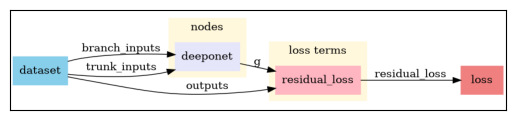

In [28]:
problem = Problem(nodes=[node_deeponet], loss=loss, grad_inference=True)
problem.show()  # graphviz library needed for graph visualization

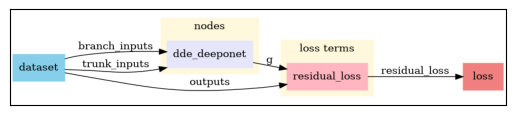

In [29]:
problem_dde = Problem(nodes=[node_dde_deeponet], loss=loss, grad_inference=True)
problem_dde.show()  # graphviz library needed for graph visualization

## Problem Solution in NeuroMANCER

In [30]:
lr = 0.001  # step size for gradient descent
epochs = 10000  # number of training epochs
epoch_verbose = 10  # print loss/display loss plot when this many epochs have occurred
warmup = 100  # number of epochs to wait before enacting early stopping policy
patience = 0  # number of epochs with no improvement in eval metric to allow before early stopping

optimizer = torch.optim.AdamW(problem.parameters(), lr=lr)

### Construct Trainer and solve the problem

In [31]:
from neuromancer.trainer import Trainer
from neuromancer.callbacks import LossHistoryCallback

# define loss history callback using plots
loss_history_callback = LossHistoryCallback(plots_dir=None, show=True)

# define trainer
trainer = Trainer(
    problem.to(device),
    train_data=train_loader,
    dev_data=dev_loader,
    test_data=test_loader,
    optimizer=optimizer,
    logger=None,
    callback=loss_history_callback,
    epochs=epochs,
    patience=patience,
    epoch_verbose=epoch_verbose,
    train_metric="train_loss",
    dev_metric="dev_loss",
    test_metric="test_loss",
    eval_metric="dev_loss",
    warmup=warmup,
    device=device,
)

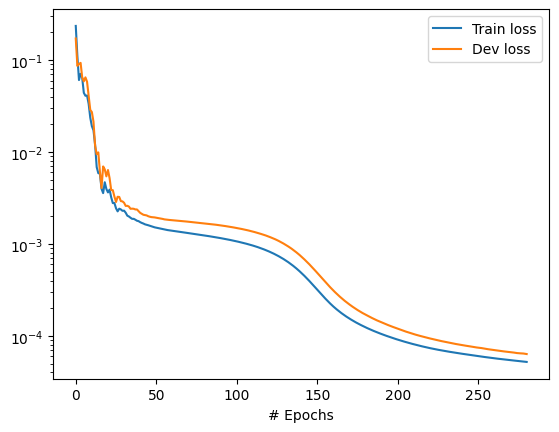

Early stopping!!!
CPU times: user 8.9 s, sys: 971 ms, total: 9.88 s
Wall time: 10.7 s


In [32]:
%%time
best_model = trainer.train()

In [33]:
# load best trained model
best_outputs = trainer.test(best_model)
problem.load_state_dict(best_model)

<All keys matched successfully>

In [34]:
train_loss_history = [l.detach().cpu().numpy() for l in trainer.loss_history["train"]]
dev_loss_history = [l.detach().cpu().numpy() for l in trainer.loss_history["dev"]]
mean_test_loss = best_outputs["mean_test_loss"].detach().cpu().numpy()
print(mean_test_loss)
print(f"len(train_loss_history): {len(train_loss_history)}")
print(f"len(dev_loss_history): {len(dev_loss_history)}")

7.593459e-05
len(train_loss_history): 286
len(dev_loss_history): 286


## Plot loss history w/ mean test loss

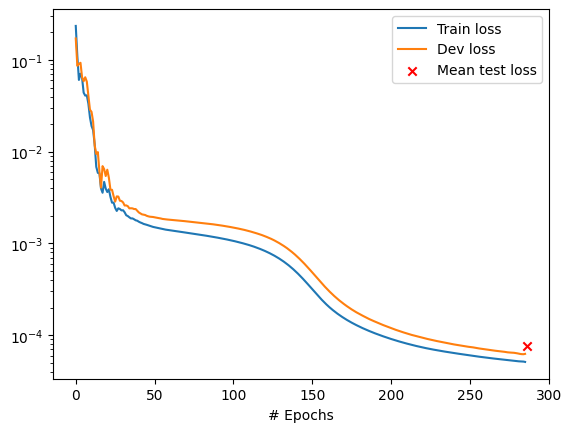

In [35]:
plt.semilogy(train_loss_history, label="Train loss")
plt.semilogy(dev_loss_history, label="Dev loss")
plt.scatter(
    len(train_loss_history), mean_test_loss, label="Mean test loss", c="red", marker="x"
)
plt.xlabel("# Epochs")
plt.legend()
plt.show()

## Compare results on the test data

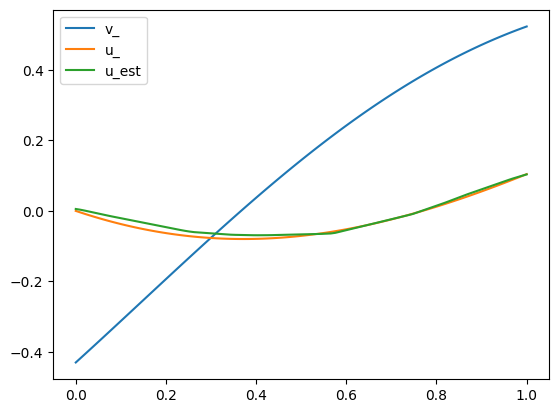

In [36]:
# Evaluate on a test function
k = 211  # k-th test function
v_ = test_datadict.datadict["branch_inputs"][k : k + 1].to(device)  # (1, m)
x_ = test_datadict.datadict["trunk_inputs"][k : k + 1].to(device)  # (1, m, 1)

res = problem.predict({"branch_inputs": v_, "trunk_inputs": x_})

u_true = test_datadict.datadict["outputs"][k].to(device)  # (m,)
u_est = res["g"][0]  # (m,)
grid = x_[0, :, 0].detach().cpu().numpy()

plt.plot(grid, v_[0].detach().cpu().numpy(), label="v_")
plt.plot(grid, u_true.detach().cpu().numpy(), label="u_")
plt.plot(grid, u_est.detach().cpu().numpy(), label="u_est")
plt.legend()


## Symbolic Integral Examples

Evaluate on the function $v(x) = x^2$

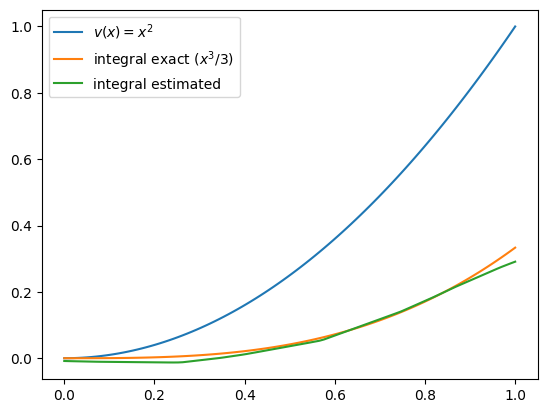

In [37]:
# Evaluate on the function v(x) = x^2

grid = train_datadict.datadict["trunk_inputs"][0]  # (m, 1)
x_ = grid.unsqueeze(0).to(device)  # (1, m, 1)
v_ = torch.pow(grid[:, 0], 2).unsqueeze(0).to(device)  # (1, m)

res = problem.predict({"branch_inputs": v_, "trunk_inputs": x_})

u_true = (1.0 / 3.0) * torch.pow(grid[:, 0], 3)  # (m,)
u_est = res["g"][0]  # (m,)
grid_np = grid[:, 0].detach().cpu().numpy()

plt.plot(grid_np, v_[0].detach().cpu().numpy(), label="$v(x) = x^2$")
plt.plot(grid_np, u_true.detach().cpu().numpy(), label="integral exact ($x^3/3$)")
plt.plot(grid_np, u_est.detach().cpu().numpy(), label="integral estimated")
plt.legend()


Evaluate on the function $v(x) = cos(x)$

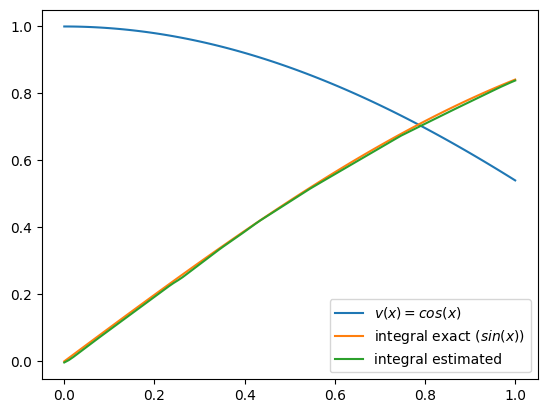

In [38]:
# Evaluate on the function v(x) = cos(x)

grid = train_datadict.datadict["trunk_inputs"][0]  # (m, 1)
x_ = grid.unsqueeze(0).to(device)  # (1, m, 1)
v_ = torch.cos(grid[:, 0]).unsqueeze(0).to(device)  # (1, m)

res = problem.predict({"branch_inputs": v_, "trunk_inputs": x_})

u_true = torch.sin(grid[:, 0])  # (m,)
u_est = res["g"][0]  # (m,)
grid_np = grid[:, 0].detach().cpu().numpy()

plt.plot(grid_np, v_[0].detach().cpu().numpy(), label="$v(x) = cos(x)$")
plt.plot(grid_np, u_true.detach().cpu().numpy(), label="integral exact ($sin(x)$)")
plt.plot(grid_np, u_est.detach().cpu().numpy(), label="integral estimated")
plt.legend()


### Comparison with problem_dde
Conpare the predictions on test data using the `dde.nn.DeepONet`

In [39]:
loss_history_callback_dde = LossHistoryCallback(plots_dir=None, show=True)
optimizer_dde = torch.optim.AdamW(problem_dde.parameters(), lr=lr)

trainer_dde = Trainer(
    problem_dde.to(device),
    train_data=train_loader,
    dev_data=dev_loader,
    test_data=test_loader,
    optimizer=optimizer_dde,
    logger=None,
    callback=loss_history_callback_dde,
    epochs=epochs,
    patience=patience,
    epoch_verbose=epoch_verbose,
    train_metric="train_loss",
    dev_metric="dev_loss",
    test_metric="test_loss",
    eval_metric="dev_loss",
    warmup=warmup,
    device=device,
)

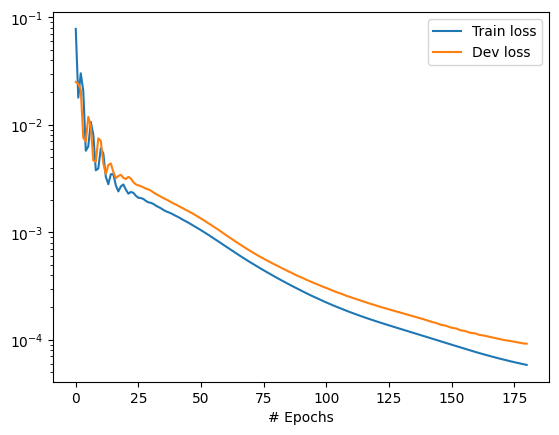

Early stopping!!!


In [40]:
best_model_dde = trainer_dde.train()


In [41]:
best_outputs_dde = trainer_dde.test(best_model_dde)
problem_dde.load_state_dict(best_model_dde)


<All keys matched successfully>

In [42]:
train_loss_history = [l.detach().cpu().numpy() for l in trainer.loss_history["train"]]
dev_loss_history = [l.detach().cpu().numpy() for l in trainer.loss_history["dev"]]

train_loss_history_dde = [
    l.detach().cpu().numpy() for l in trainer_dde.loss_history["train"]
]
dev_loss_history_dde = [
    l.detach().cpu().numpy() for l in trainer_dde.loss_history["dev"]
]

mean_test_loss = best_outputs["mean_test_loss"].detach().cpu().numpy()
mean_test_loss_dde = best_outputs_dde["mean_test_loss"].detach().cpu().numpy()
print("baseline test:", mean_test_loss)
print("DeepXDE test:", mean_test_loss_dde)

baseline test: 7.593459e-05
DeepXDE test: 7.38913e-05


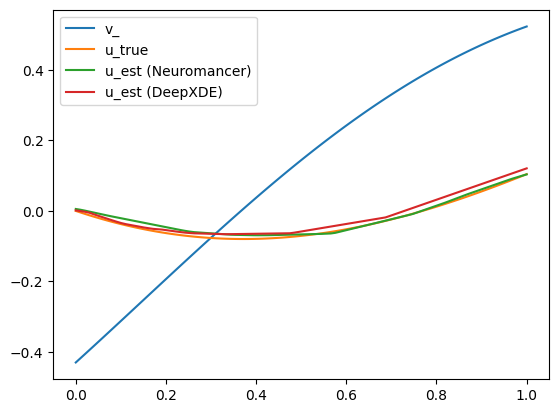

In [43]:
# Compare both models on one test sample
k = 211  # test index
v_ = test_datadict.datadict["branch_inputs"][k : k + 1].to(device)
x_ = test_datadict.datadict["trunk_inputs"][k : k + 1].to(device)

res_base = problem.predict({"branch_inputs": v_, "trunk_inputs": x_})
res_dde = problem_dde.predict({"branch_inputs": v_, "trunk_inputs": x_})

u_true = test_datadict.datadict["outputs"][k].to(device)
u_est_base = res_base["g"][0]
u_est_dde = res_dde["g"][0]
grid = x_[0, :, 0].detach().cpu().numpy()

plt.plot(grid, v_[0].detach().cpu().numpy(), label="v_")
plt.plot(grid, u_true.detach().cpu().numpy(), label="u_true")
plt.plot(grid, u_est_base.detach().cpu().numpy(), label="u_est (Neuromancer)")
plt.plot(grid, u_est_dde.detach().cpu().numpy(), label="u_est (DeepXDE)")
plt.legend()
plt.show()
